In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("train.csv", sep=',', header=None, names=['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])
df

C:\Users\darkl\AppData\Local\Temp\ipykernel_23372\2286785260.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv", sep=',', header=None, names=['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'])


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
...,...,...,...,...,...,...,...
ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [9]:
df.isnull().sum()

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [10]:
df['comment_text'] = df['comment_text'].apply(lambda x: str(x).lower())
df

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0000997932d777bf,explanation\nwhy the edits made under my usern...,0,0,0,0,0,0
000103f0d9cfb60f,d'aww! he matches this background colour i'm s...,0,0,0,0,0,0
000113f07ec002fd,"hey man, i'm really not trying to edit war. it...",0,0,0,0,0,0
0001b41b1c6bb37e,"""\nmore\ni can't make any real suggestions on ...",0,0,0,0,0,0
...,...,...,...,...,...,...,...
ffe987279560d7ff,""":::::and for the second time of asking, when ...",0,0,0,0,0,0
ffea4adeee384e90,you should be ashamed of yourself \n\nthat is ...,0,0,0,0,0,0
ffee36eab5c267c9,"spitzer \n\numm, theres no actual article for ...",0,0,0,0,0,0
fff125370e4aaaf3,and it looks like it was actually you who put ...,0,0,0,0,0,0


In [11]:
import string
import nltk
from streamlit import form
from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize
from bs4 import BeautifulSoup
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')




def remove_punctuation(comment_text):
    return comment_text.translate(str.maketrans('', '', string.punctuation))


def remove_numbers(comment_text):
    new = ''
    for i in comment_text:
        if not i.isdigit():
            new += i
    return new



def remove_emojis(comment_text):
    new = ''
    for i in comment_text:
        if i.isascii():
            new += i
    return new



def remove_html_tags(comment_text):
    soup = BeautifulSoup(comment_text, "html.parser")
    return soup.get_text()


stop_words = set(stopwords.words('english'))

def remove_stopwords(comment_text):
    return ' '.join(
        word for word in comment_text.split()
        if word not in stop_words
    )

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\darkl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\darkl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\darkl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [12]:
def clean_text(text):
    text = remove_html_tags(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_emojis(text)
    text = remove_stopwords(text)
    return text

df['comment_text'] = df['comment_text'].apply(clean_text)
df

C:\Users\darkl\AppData\Local\Temp\ipykernel_23372\473577402.py:38: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a URL than HTML or XML.

If you meant to use Beautiful Soup to parse the web page found at a certain URL, then something has gone wrong. You should use an Python package like 'requests' to fetch the content behind the URL. Once you have the content as a string, you can feed that string into Beautiful Soup.

However, if you want to parse some data that happens to look like a URL, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  soup = BeautifulSoup(comment_text, "html.parser")


,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
id,commenttext,toxic,severe_toxic,obscene,threat,insult,identity_hate
0000997932d777bf,explanation edits made username hardcore metal...,0,0,0,0,0,0
000103f0d9cfb60f,daww matches background colour im seemingly st...,0,0,0,0,0,0
000113f07ec002fd,hey man im really trying edit war guy constant...,0,0,0,0,0,0
0001b41b1c6bb37e,cant make real suggestions improvement wondere...,0,0,0,0,0,0
...,...,...,...,...,...,...,...
ffe987279560d7ff,second time asking view completely contradicts...,0,0,0,0,0,0
ffea4adeee384e90,ashamed horrible thing put talk page,0,0,0,0,0,0
ffee36eab5c267c9,spitzer umm theres actual article prostitution...,0,0,0,0,0,0
fff125370e4aaaf3,looks like actually put speedy first version d...,0,0,0,0,0,0


In [13]:
df.isnull().sum()

comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

EDA

In [14]:
df.dtypes

comment_text     object
toxic            object
severe_toxic     object
obscene          object
threat           object
insult           object
identity_hate    object
dtype: object

Toxic

In [15]:
df['toxic'].dtype
df['toxic'].value_counts()

toxic
0        85089
0        59188
1         8947
1         6347
toxic        1
Name: count, dtype: int64

In [16]:
df['toxic'] = pd.to_numeric(df['toxic'], errors='coerce')
df = df.dropna(subset=['toxic'])
df['toxic'] = df['toxic'].astype(int)
df['toxic'].value_counts()

C:\Users\darkl\AppData\Local\Temp\ipykernel_23372\1211995600.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['toxic'] = df['toxic'].astype(int)


toxic
0    144277
1     15294
Name: count, dtype: int64

In [17]:
print(df['toxic'].isnull().sum())
print(df['toxic'].dtype)

0
int64


Severe_toxic

In [18]:
print(df['severe_toxic'].dtype)
print(df['severe_toxic'].value_counts())


object
severe_toxic
0    93092
0    64884
1      944
1      651
Name: count, dtype: int64


In [19]:
df['severe_toxic'] = pd.to_numeric(df['severe_toxic'], errors='coerce')
df = df.dropna(subset=['severe_toxic'])
df['severe_toxic'] = df['severe_toxic'].astype(int)


print(df['severe_toxic'].isnull().sum())
print(df['severe_toxic'].dtype)

0
int64


C:\Users\darkl\AppData\Local\Temp\ipykernel_23372\4092644735.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['severe_toxic'] = pd.to_numeric(df['severe_toxic'], errors='coerce')


Obscene

In [20]:
print(df['obscene'].dtype)
print(df['obscene'].value_counts())


object
obscene
0    89046
0    62076
1     4990
1     3459
Name: count, dtype: int64


In [21]:
df['obscene'] = pd.to_numeric(df['obscene'], errors='coerce')
df = df.dropna(subset=['obscene'])
df['obscene'] = df['obscene'].astype(int)


print(df['obscene'].isnull().sum())
print(df['obscene'].dtype)

0
int64


Threat

In [22]:
print(df['threat'].dtype)
print(df['threat'].value_counts())


object
threat
0    93780
0    65313
1      256
1      222
Name: count, dtype: int64


In [23]:
df['threat'] = pd.to_numeric(df['threat'], errors='coerce')
df = df.dropna(subset=['threat'])
df['threat'] = df['threat'].astype(int)


print(df['threat'].isnull().sum())
print(df['threat'].dtype)

0
int64


Insult

In [24]:
print(df['insult'].dtype)
print(df['insult'].value_counts())


object
insult
0    89384
0    62310
1     4652
1     3225
Name: count, dtype: int64


In [25]:
df['insult'] = pd.to_numeric(df['insult'], errors='coerce')
df = df.dropna(subset=['insult'])
df['insult'] = df['insult'].astype(int)


print(df['insult'].isnull().sum())
print(df['insult'].dtype)

0
int64


identity_hate

In [26]:
print(df['identity_hate'].dtype)
print(df['identity_hate'].value_counts())


object
identity_hate
0    93200
0    64966
1      836
1      569
Name: count, dtype: int64


In [27]:
df['identity_hate'] = pd.to_numeric(df['identity_hate'], errors='coerce')
df = df.dropna(subset=['identity_hate'])
df['identity_hate'] = df['identity_hate'].astype(int)


print(df['identity_hate'].isnull().sum())
print(df['identity_hate'].dtype)

0
int64


In [28]:
df

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0000997932d777bf,explanation edits made username hardcore metal...,0,0,0,0,0,0
000103f0d9cfb60f,daww matches background colour im seemingly st...,0,0,0,0,0,0
000113f07ec002fd,hey man im really trying edit war guy constant...,0,0,0,0,0,0
0001b41b1c6bb37e,cant make real suggestions improvement wondere...,0,0,0,0,0,0
0001d958c54c6e35,sir hero chance remember page thats,0,0,0,0,0,0
...,...,...,...,...,...,...,...
ffe987279560d7ff,second time asking view completely contradicts...,0,0,0,0,0,0
ffea4adeee384e90,ashamed horrible thing put talk page,0,0,0,0,0,0
ffee36eab5c267c9,spitzer umm theres actual article prostitution...,0,0,0,0,0,0
fff125370e4aaaf3,looks like actually put speedy first version d...,0,0,0,0,0,0


In [29]:
print(df.shape)
print('\n',df.dtypes)
print('\n',df.isnull().sum())
print('\n The number of duplicated comments is:',df['comment_text'].duplicated().sum())

(159571, 7)

 comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

 comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

 The number of duplicated comments is: 1713


In [30]:
duplicates = df[df['comment_text'].duplicated(keep=False)]

duplicates.sort_values('comment_text').head(20)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
99c87b34227da6ff,,0,0,0,0,0,0
efc3c00d27528857,,0,0,0,0,0,0
ac14106a1572f89f,,0,0,0,0,0,0
067638a445ccd93b,,0,0,0,0,0,0
813bed65fd893a9c,,0,0,0,0,0,0
dc05e79cd9a50e0d,,0,0,0,0,0,0
9aa98f88036d0a66,,0,0,0,0,0,0
528b079a22ccbfb0,,0,0,0,0,0,0
fc07c300533d28e4,,0,0,0,0,0,0
2c6b162ebc5f59d5,,0,0,0,0,0,0


In [31]:
df = df[df['comment_text'].str.strip() != '']

In [32]:
print("Duplicates:", df['comment_text'].duplicated().sum())

Duplicates: 1668


In [33]:
duplicates = df[df['comment_text'].duplicated(keep=False)]
duplicates.sort_values('comment_text').head(20)

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
74ea8c43fbf40882,able edit,0,0,0,0,0,0
bc1c7f9157640902,able edit,0,0,0,0,0,0
97e1db6fbef0ef5b,abortion lede please take look abortion lede,0,0,0,0,0,0
ee2bf6ef269dcc72,abortion lede please take look abortion lede,0,0,0,0,0,0
ad4b0ab3a9a3e31a,abuse user abuses speedy deletion mechanism,0,0,0,0,0,0
7388212b6a92bd24,abuse user abuses speedy deletion mechanism,0,0,0,0,0,0
4b93c8c16906f8b0,abusing bots stop idiot pedigree mislabeled ev...,1,0,1,0,0,0
26d1169ce0c1d3d1,abusing bots stop idiot pedigree mislabeled ev...,1,0,1,0,1,0
da603099db3ed03e,accept opinion godgiven law,0,0,0,0,0,0
47c9845c867e38f7,accept opinion godgiven law,0,0,0,0,0,0


In [34]:
df = df.drop_duplicates()

In [35]:
label_cols = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

class_counts = df[label_cols].sum().sort_values(ascending=False)

print(class_counts)

toxic            15214
obscene           8399
insult            7836
severe_toxic      1592
identity_hate     1397
threat             473
dtype: int64


In [36]:
df['comment_length'] = df['comment_text'].str.len()

df['comment_length'].describe()

count    157984.000000
mean        251.487189
std         390.797099
min           2.000000
25%          59.000000
50%         129.000000
75%         275.000000
max        5000.000000
Name: comment_length, dtype: float64

In [37]:
df

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,comment_length
0000997932d777bf,explanation edits made username hardcore metal...,0,0,0,0,0,0,173
000103f0d9cfb60f,daww matches background colour im seemingly st...,0,0,0,0,0,0,73
000113f07ec002fd,hey man im really trying edit war guy constant...,0,0,0,0,0,0,144
0001b41b1c6bb37e,cant make real suggestions improvement wondere...,0,0,0,0,0,0,377
0001d958c54c6e35,sir hero chance remember page thats,0,0,0,0,0,0,35
...,...,...,...,...,...,...,...,...
ffe987279560d7ff,second time asking view completely contradicts...,0,0,0,0,0,0,186
ffea4adeee384e90,ashamed horrible thing put talk page,0,0,0,0,0,0,36
ffee36eab5c267c9,spitzer umm theres actual article prostitution...,0,0,0,0,0,0,66
fff125370e4aaaf3,looks like actually put speedy first version d...,0,0,0,0,0,0,57


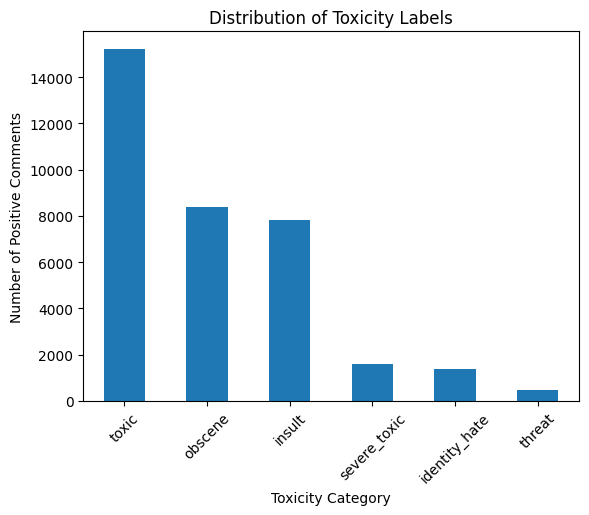

In [38]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')

plt.title('Distribution of Toxicity Labels')
plt.xlabel('Toxicity Category')
plt.ylabel('Number of Positive Comments')
plt.xticks(rotation=45)
plt.show()

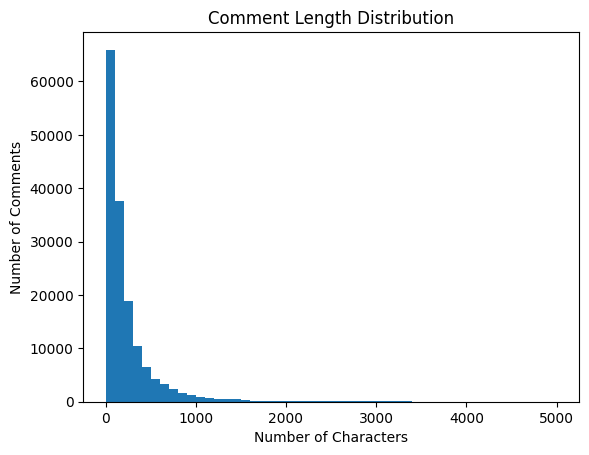

In [39]:
import matplotlib.pyplot as plt

plt.hist(df['comment_length'], bins=50)
plt.title('Comment Length Distribution')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Comments')
plt.show()

In [40]:
class_percentage = (df[label_cols].mean() * 100).sort_values(ascending=False)

print(class_percentage)

toxic            9.630089
obscene          5.316361
insult           4.959996
severe_toxic     1.007697
identity_hate    0.884267
threat           0.299397
dtype: float64


Now doing all the ml parts

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC

In [42]:
x = df['comment_text']
y = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [43]:
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (126387,)
X_test: (31597,)
y_train: (126387, 6)
y_test: (31597, 6)


Using TF-IDF Vectorization and Logistic Regression for Multi-label Classification

In [44]:
tfidf_vectorizer = TfidfVectorizer()
x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

print("X_train_tfidf:", x_train_tfidf.shape)
print("\nX_test_tfidf:", x_test_tfidf.shape)

X_train_tfidf: (126387, 193401)

X_test_tfidf: (31597, 193401)


In [45]:
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model.fit(x_train_tfidf, y_train)
y_pred_lgre = model.predict(x_test_tfidf)
# print(classification_report(y_test, y_pred, target_names=y.columns))
accuracy = accuracy_score(y_test, y_pred_lgre)

In [46]:
print("Accuracy in all of the classes:\n")
for i, col in enumerate(y_test.columns):
    print(
        col,
        "Accuracy: ",
        accuracy_score(y_test[col], y_pred_lgre[:, i])*100,"%"
    )


print("\nAverage Accuracy:", accuracy_score(y_test, y_pred_lgre)*100,"%")

Accuracy in all of the classes:

toxic Accuracy:  95.61034275405893 %
severe_toxic Accuracy:  99.02205905623951 %
obscene Accuracy:  97.77194037408616 %
threat Accuracy:  99.7183276893376 %
insult Accuracy:  97.06301231129537 %
identity_hate Accuracy:  99.1897964996677 %

Average Accuracy: 91.91378928379277 %


In [47]:
print('Classification report logistic regression: \n',classification_report(
    y_test,
    y_pred_lgre,
    target_names=y_test.columns
))

Classification report logistic regression: 
                precision    recall  f1-score   support

        toxic       0.91      0.60      0.72      3032
 severe_toxic       0.47      0.23      0.31       299
      obscene       0.91      0.64      0.76      1687
       threat       0.69      0.18      0.29        99
       insult       0.82      0.52      0.64      1559
identity_hate       0.63      0.16      0.25       274

    micro avg       0.87      0.55      0.68      6950
    macro avg       0.74      0.39      0.49      6950
 weighted avg       0.86      0.55      0.67      6950
  samples avg       0.05      0.05      0.05      6950



c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

Balanced Logistic Regression

In [48]:
model = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))
model.fit(x_train_tfidf, y_train)
y_pred_blgre = model.predict(x_test_tfidf)
# print(classification_report(y_test, y_pred, target_names=y.columns))

In [49]:
print('Classification report of Balanced Logistic Regression: \n',classification_report(
    y_test,
    y_pred_blgre,
    target_names=y_test.columns
))

Classification report of Balanced Logistic Regression: 
                precision    recall  f1-score   support

        toxic       0.64      0.84      0.73      3032
 severe_toxic       0.26      0.85      0.40       299
      obscene       0.68      0.90      0.78      1687
       threat       0.24      0.76      0.36        99
       insult       0.54      0.87      0.67      1559
identity_hate       0.25      0.81      0.38       274

    micro avg       0.55      0.86      0.67      6950
    macro avg       0.44      0.84      0.55      6950
 weighted avg       0.59      0.86      0.69      6950
  samples avg       0.06      0.08      0.07      6950



c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

LinearSVC with One-vs-Rest:

In [50]:
model_svc = OneVsRestClassifier(LinearSVC(class_weight='balanced', max_iter=10000))

model_svc.fit(x_train_tfidf, y_train)

y_pred_svc = model_svc.predict(x_test_tfidf)

In [51]:
print('Classification report of Balanced Linear SVC: \n',classification_report(
    y_test,
    y_pred_svc,
    target_names=y_test.columns
))

Classification report of Balanced Linear SVC: 
                precision    recall  f1-score   support

        toxic       0.70      0.81      0.75      3032
 severe_toxic       0.32      0.63      0.42       299
      obscene       0.76      0.85      0.80      1687
       threat       0.44      0.55      0.48        99
       insult       0.60      0.78      0.68      1559
identity_hate       0.38      0.57      0.46       274

    micro avg       0.64      0.79      0.71      6950
    macro avg       0.53      0.70      0.60      6950
 weighted avg       0.66      0.79      0.72      6950
  samples avg       0.06      0.07      0.07      6950



c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darkl\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

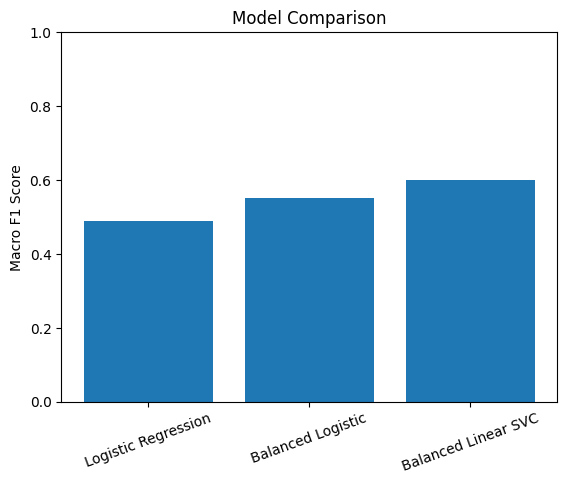

In [52]:
models = [
    'Logistic Regression',
    'Balanced Logistic',
    'Balanced Linear SVC'
]

macro_f1 = [0.49, 0.55, 0.60]

plt.bar(models, macro_f1)
plt.ylabel('Macro F1 Score')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

In [53]:
import joblib

joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(model_svc, "toxic_comment_model.pkl")

['toxic_comment_model.pkl']